In [19]:
# Install required package
!pip install xgboost

In [20]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [21]:
# Load Dataset
df = pd.read_csv("cardio_train.csv", sep=';')
print("Dataset shape:", df.shape)
print("Missing values:\n", df.isnull().sum())

Dataset shape: (70000, 13)
Missing values:
 id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


In [22]:
# Data Cleaning & Preprocessing

# Remove unnecessary ID column
df = df.drop(columns=['id'])

# Convert age from days to years for interpretability
df['age'] = df['age'] / 365

# Remove unrealistic blood pressure values
df = df[df['ap_hi'] > df['ap_lo']]
df = df[(df['ap_hi'] < 250) & (df['ap_lo'] < 150)]

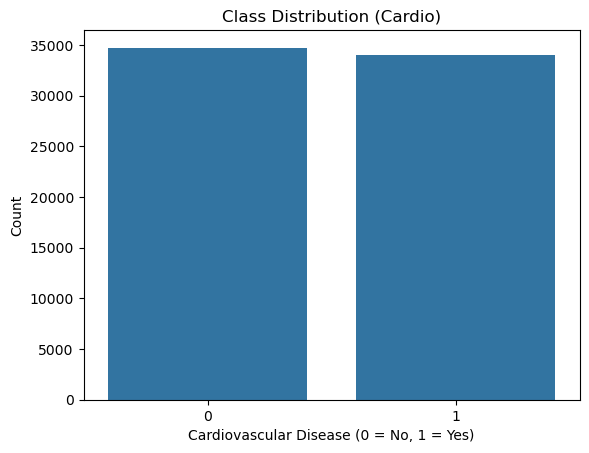

In [23]:
# Feature Selection
X = df.drop('cardio', axis=1)     # Input features
y = df['cardio']                  # Target variable (0 = no disease, 1 = disease)

# Visualize class distribution (important for imbalance detection)
sns.countplot(x=y)
plt.title("Class Distribution (Cardio)")
plt.xlabel("Cardiovascular Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [24]:
# Feature Engineering
categorical_cols = ["gender", "cholesterol", "gluc"]
numerical_cols = [col for col in X.columns if col not in categorical_cols]

from sklearn.preprocessing import OneHotEncoder

# One-hot encode categorical variables
# Standard scale numerical features
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(drop="first"), categorical_cols)
    ]
)

In [25]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
# Model 1: Logistic Regression Pipeline (with class balancing)
lr_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

In [27]:
# Model 2: Random Forest (with class balancing)
rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    ))
])

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [28]:
# Random Forest (Grid Search)
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, None]
}

grid = GridSearchCV(
    estimator=Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(class_weight="balanced"))
    ]),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred_best_rf))

Best Params: {'model__max_depth': 10, 'model__n_estimators': 200}
Best CV Score: 0.7353427190803897
Test Accuracy: 0.7266443538998836


In [29]:
# Model 3: XGBoost (handles imbalance via scale_pos_weight)

# Class Imbalance Ratio
ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss",
        scale_pos_weight=ratio
    ))
])

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# ROC-AUC (important for classification performance)
xgb_probs = xgb.predict_proba(X_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, xgb_probs))

Accuracy: 0.7243160651920838
ROC-AUC: 0.7915892252319007


In [30]:
# Hyperparameter Tuning (Random Forest)
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced'),
    param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best RF Params:", grid.best_params_)
print("Best RF Score:", grid.best_score_)

Best RF Params: {'max_depth': 10, 'n_estimators': 200}
Best RF Score: 0.7359429538771117


In [31]:
# Model Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nRandom Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("\nLogistic Regression Report:\n")
print(classification_report(y_test, y_pred_lr))

print("\nXGBoost Report:\n")
print(classification_report(y_test, y_pred_xgb))

Logistic Regression Accuracy: 0.7226426076833528
Random Forest Accuracy: 0.7104918509895227
XGBoost Accuracy: 0.7243160651920838

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.73      0.72      6999
           1       0.71      0.69      0.70      6745

    accuracy                           0.71     13744
   macro avg       0.71      0.71      0.71     13744
weighted avg       0.71      0.71      0.71     13744


Logistic Regression Report:

              precision    recall  f1-score   support

           0       0.71      0.78      0.74      6999
           1       0.74      0.66      0.70      6745

    accuracy                           0.72     13744
   macro avg       0.72      0.72      0.72     13744
weighted avg       0.72      0.72      0.72     13744


XGBoost Report:

              precision    recall  f1-score   support

           0       0.71      0.77      0.74      6999
           1       0.

In [32]:
# Logistic Regression pipeline (fixes scaling + convergence)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

# Cross-validation (consistent across models)
lr_cv = cross_val_score(lr_pipeline, X, y, cv=5)
rf_cv = cross_val_score(rf, X, y, cv=5)
xgb_cv = cross_val_score(xgb, X, y, cv=5)

print("LR CV:", lr_cv.mean())
print("RF CV:", rf_cv.mean())
print("XGB CV:", xgb_cv.mean())

LR CV: 0.7276074444757017
RF CV: 0.7130112296771338
XGB CV: 0.7308089272159466


In [33]:
# Feature Importance (XGBoost)

# Get trained model from pipeline
model = xgb.named_steps["model"]

# Get feature names after preprocessing
feature_names = xgb.named_steps["preprocess"].get_feature_names_out()

# Get feature importances
importances = model.feature_importances_

# Safety check 
print("Feature names:", len(feature_names))
print("Importances:", len(importances))

# Align lengths safely 
min_len = min(len(feature_names), len(importances))

fi_df = pd.DataFrame({
    "feature": feature_names[:min_len],
    "importance": importances[:min_len]
}).sort_values(by="importance", ascending=False)

print("\nTop 10 Important Features:\n")
print(fi_df.head(10))

Feature names: 13
Importances: 13

Top 10 Important Features:

               feature  importance
3           num__ap_hi    0.384159
10  cat__cholesterol_3    0.273317
0             num__age    0.046488
12         cat__gluc_3    0.045352
9   cat__cholesterol_2    0.037486
6            num__alco    0.037025
7          num__active    0.035334
5           num__smoke    0.027613
4           num__ap_lo    0.024186
11         cat__gluc_2    0.023988


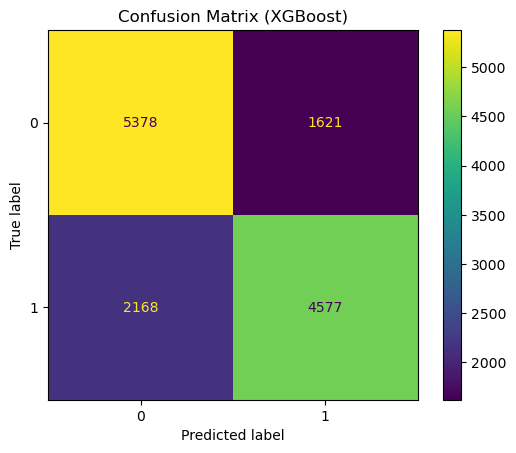

In [34]:
# Confusion Matrix (XGBoost)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, xgb.predict(X_test))
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix (XGBoost)")
plt.show()

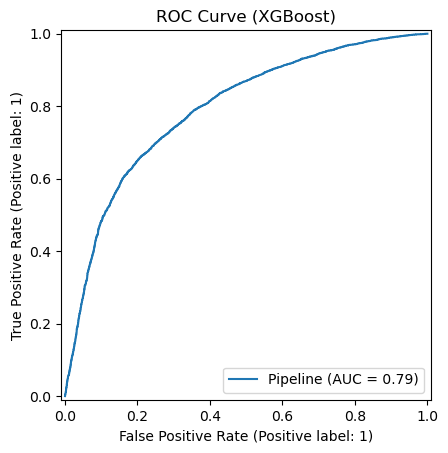

In [35]:
# ROC Curve (XGBoost)
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(xgb, X_test, y_test)
plt.title("ROC Curve (XGBoost)")
plt.show()

In [36]:
# Evaluate Tuned Random Forest
best_rf = grid.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("\nTuned Random Forest Report:\n")
print(classification_report(y_test, y_pred_best_rf))

print("Original RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best_rf))


Tuned Random Forest Report:

              precision    recall  f1-score   support

           0       0.71      0.78      0.75      6999
           1       0.75      0.67      0.71      6745

    accuracy                           0.73     13744
   macro avg       0.73      0.73      0.73     13744
weighted avg       0.73      0.73      0.73     13744

Original RF Accuracy: 0.7104918509895227
Tuned Random Forest Accuracy: 0.726789871944121
